<a href="https://colab.research.google.com/github/marciaeklu20-lab/gimpa-smart-resource-mgt/blob/feature%2Ffull-build/gimpa-resource-mgt-main/notebooks/gimpa_capstone_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GIMPA Smart Resource Management — Capstone Analysis

This notebook applies data science and machine learning techniques to the
GIMPA Smart Resource Management System dataset. We use a combination of
exploratory data analysis (EDA), time-series forecasting, unsupervised
clustering, NLP-driven fault analysis, and supervised classification to
extract operational insights and demonstrate the system's analytical
potential beyond CRUD operations.

## Outline

1. **Setup & Data Generation** — Bootstrap a realistic synthetic dataset
   representing 6 months of operational activity
2. **Exploratory Data Analysis** — Distributions, correlations, temporal patterns
3. **Booking Demand Forecasting** — Time-series modeling (Prophet) for the next
   4 weeks of booking volume
4. **Resource Utilization Clustering** — Unsupervised grouping (K-Means + PCA)
   to surface over- and under-used resources
5. **Fault Pattern Analysis** — NLP clustering (TF-IDF + DBSCAN) on fault
   descriptions to identify systemic issues
6. **Predictive Maintenance** — Supervised learning (Random Forest) estimating
   per-resource fault likelihood
7. **Conclusions & Recommendations** — Synthesis and operational guidance

## Reproducibility

- Random seed: `42` (fixed throughout)
- Synthetic dataset: 6 months of activity, ~50 resources, ~30 users
- Environment: Google Colab default + Prophet


In [6]:
# Cell 2 — Imports & environment setup

import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Reproducibility — fix random seeds everywhere
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Plotting defaults
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Prophet is not in Colab's default image — install if missing
try:
    from prophet import Prophet
    print("Prophet already available.")
except ImportError:
    print("Installing Prophet (this takes ~60 seconds the first time)...")
    %pip install prophet --quiet
    from prophet import Prophet
    print("Prophet installed.")

print()
print(f"NumPy   {np.__version__}")
print(f"pandas  {pd.__version__}")
print(f"seaborn {sns.__version__}")
print(f"Random seed pinned at {RANDOM_SEED}")

Prophet already available.

NumPy   2.0.2
pandas  2.2.2
seaborn 0.13.2
Random seed pinned at 42


---

## Section 1 — Synthetic Data Generation

The deployed system has been running for a short period and lacks the
volume of historical activity required to demonstrate ML techniques
meaningfully. We generate a realistic synthetic dataset modelling 6
months (180 days) of operational activity across:

- **Resources** — ~50 physical/digital assets across 8 categories
- **Users** — 30 users with role distribution mirroring GIMPA's organisational structure
- **Bookings** — ~1,500–2,000 records with realistic weekly and daily cyclical patterns
- **Faults** — ~25–50 records with severity-weighted distribution and resolution times
- **Supply Requests** — ~25–40 records with category-clustered item names

All randomness uses `RANDOM_SEED = 42` (pinned in Cell 2) so the analysis
is fully reproducible. The synthetic generator does not attempt to model
COVID disruptions, Ghana-specific holidays, or faculty-specific demand
cycles — these are documented as limitations in Section 7.

In [7]:
# Cell 4 — Generate resources DataFrame

RESOURCE_CATEGORIES = [
    # (category, type, count, capacity_range, condition_weights[excellent,good,fair,poor,oos])
    ("Lecture Hall",    "room",      8,  (50, 200),  [0.40, 0.40, 0.15, 0.04, 0.01]),
    ("Lab",             "room",      6,  (20, 40),   [0.30, 0.40, 0.20, 0.08, 0.02]),
    ("Meeting Room",    "room",      6,  (8, 20),    [0.50, 0.35, 0.10, 0.04, 0.01]),
    ("Conference Hall", "venue",     2,  (200, 500), [0.50, 0.40, 0.10, 0.00, 0.00]),
    ("Projector",       "equipment", 10, (0, 0),     [0.30, 0.30, 0.25, 0.10, 0.05]),
    ("Laptop",          "equipment", 8,  (0, 0),     [0.20, 0.30, 0.30, 0.15, 0.05]),
    ("Vehicle",         "vehicle",   6,  (4, 16),    [0.20, 0.40, 0.25, 0.10, 0.05]),
    ("Audio System",    "equipment", 4,  (0, 0),     [0.30, 0.40, 0.20, 0.08, 0.02]),
]
CONDITIONS = ["excellent", "good", "fair", "poor", "out_of_service"]
LOCATIONS  = ["Main Campus", "Greenhill Campus", "Kumasi Annex"]

resources_rows = []
for category, type_, count, cap_range, cond_weights in RESOURCE_CATEGORIES:
    for i in range(1, count + 1):
        code_prefix = category.split()[0][:3].upper()
        asset_code = f"{code_prefix}-{i:03d}"
        capacity = (
            np.random.randint(cap_range[0], cap_range[1] + 1)
            if cap_range[1] > 0 else 0
        )
        resources_rows.append({
            "assetCode":  asset_code,
            "name":       f"{category} {i}",
            "category":   category,
            "type":       type_,
            "capacity":   capacity,
            "condition":  np.random.choice(CONDITIONS, p=cond_weights),
            "location":   np.random.choice(LOCATIONS),
        })

resources_df = pd.DataFrame(resources_rows)
print(f"Generated {len(resources_df)} resources across {resources_df['category'].nunique()} categories.\n")
print("Condition distribution:")
print(resources_df["condition"].value_counts().to_string())
resources_df.head(8)

Generated 50 resources across 8 categories.

Condition distribution:
condition
good              21
excellent         18
fair               6
poor               3
out_of_service     2


,assetCode,name,category,type,capacity,condition,location
0,LEC-001,Lecture Hall 1,Lecture Hall,room,152,good,Kumasi Annex
1,LEC-002,Lecture Hall 2,Lecture Hall,room,156,good,Main Campus
2,LEC-003,Lecture Hall 3,Lecture Hall,room,152,good,Kumasi Annex
3,LEC-004,Lecture Hall 4,Lecture Hall,room,124,good,Main Campus
4,LEC-005,Lecture Hall 5,Lecture Hall,room,149,excellent,Kumasi Annex
5,LEC-006,Lecture Hall 6,Lecture Hall,room,199,excellent,Greenhill Campus
6,LEC-007,Lecture Hall 7,Lecture Hall,room,87,excellent,Main Campus
7,LEC-008,Lecture Hall 8,Lecture Hall,room,107,good,Main Campus


In [8]:
# Cell 5 — Generate users DataFrame

ROLE_DISTRIBUTION = [
    ("Lecturer",                  0.30),
    ("student",                   0.30),
    ("Teaching Assistant",        0.10),
    ("Administrative Officer",    0.05),
    ("Facility/Estate Officer",   0.04),
    ("Logistics Officer",         0.04),
    ("Stores/Inventory Officer",  0.04),
    ("Maintenance Admin",         0.03),
    ("Maintenance Staff",         0.05),
    ("Secretariat Admin",         0.02),
    ("IT Officer",                0.02),
    ("super_admin",               0.01),
]

n_users = 30
roles, weights = zip(*ROLE_DISTRIBUTION)
weights = np.array(weights)
weights = weights / weights.sum()

users_rows = []
for i in range(1, n_users + 1):
    users_rows.append({
        "userId": f"USR-{i:03d}",
        "role":   np.random.choice(roles, p=weights),
    })

users_df = pd.DataFrame(users_rows)
print(f"Generated {len(users_df)} users.\n")
print("Role distribution:")
print(users_df["role"].value_counts().to_string())

Generated 30 users.

Role distribution:
role
Lecturer                    11
student                      7
Logistics Officer            4
Maintenance Admin            3
Maintenance Staff            2
Facility/Estate Officer      1
Teaching Assistant           1
Stores/Inventory Officer     1


In [9]:
# Cell 6 — Generate bookings with realistic weekly + daily patterns

PERIOD_DAYS = 180
END_DATE    = datetime(2026, 6, 1)
START_DATE  = END_DATE - timedelta(days=PERIOD_DAYS)

# Day-of-week multiplier: weekdays much busier than weekends
DAY_MULTIPLIER = {0: 1.0, 1: 1.1, 2: 1.1, 3: 1.0, 4: 0.8, 5: 0.2, 6: 0.1}

def booking_weight(category):
    return {
        "Lecture Hall": 3.0, "Lab": 2.5, "Meeting Room": 2.0,
        "Conference Hall": 1.5, "Vehicle": 1.5,
        "Projector": 1.2, "Laptop": 0.8, "Audio System": 0.6,
    }.get(category, 1.0)

BOOKER_ROLES = {
    "Lecturer", "Teaching Assistant", "Administrative Officer",
    "Higher Level Management", "Secretariat Admin", "IT Officer",
    "Facility/Estate Officer", "Logistics Officer",
    "Stores/Inventory Officer", "Maintenance Admin", "super_admin"
}
bookers = users_df[users_df["role"].isin(BOOKER_ROLES)].copy()
print(f"{len(bookers)} of {len(users_df)} users are booker-eligible.\n")

resource_weights = resources_df["category"].apply(booking_weight).values
resource_weights = resource_weights / resource_weights.sum()

BOOKINGS_PER_DAY_AVG = 10
STATUS_DIST = {"confirmed": 0.60, "pending": 0.15, "cancelled": 0.15, "completed": 0.10}
statuses, status_probs = zip(*STATUS_DIST.items())

bookings_rows = []
booking_id = 0

for day_offset in range(PERIOD_DAYS):
    day = START_DATE + timedelta(days=day_offset)
    day_mult = DAY_MULTIPLIER[day.weekday()]
    n_today = max(0, int(np.random.poisson(BOOKINGS_PER_DAY_AVG * day_mult)))

    for _ in range(n_today):
        booking_id += 1
        hour = max(8, min(20, int(np.random.normal(12, 3))))
        minute = np.random.choice([0, 30])
        start = day.replace(hour=hour, minute=minute, second=0, microsecond=0)
        duration_h = np.random.choice([1, 2, 3], p=[0.50, 0.35, 0.15])
        end = start + timedelta(hours=int(duration_h))

        resource = resources_df.iloc[np.random.choice(len(resources_df), p=resource_weights)]
        requester = bookers.sample(1).iloc[0]

        bookings_rows.append({
            "bookingId":    f"BKG-{booking_id:05d}",
            "resourceId":   resource["assetCode"],
            "resourceName": resource["name"],
            "category":     resource["category"],
            "requesterId":  requester["userId"],
            "startTime":    start,
            "endTime":      end,
            "status":       np.random.choice(statuses, p=status_probs),
            "createdAt":    start - timedelta(days=int(np.random.randint(0, 7))),
        })

bookings_df = pd.DataFrame(bookings_rows)
print(f"Generated {len(bookings_df)} bookings over {PERIOD_DAYS} days.")
print(f"Date range: {bookings_df['startTime'].min().date()} → {bookings_df['startTime'].max().date()}\n")
print("Volume by day of week:")
print(bookings_df.groupby(bookings_df["startTime"].dt.day_name())
      .size().reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
      .to_string())

21 of 30 users are booker-eligible.

Generated 1335 bookings over 180 days.
Date range: 2025-12-03 → 2026-05-31

Volume by day of week:
startTime
Monday       244
Tuesday      297
Wednesday    269
Thursday     235
Friday       205
Saturday      61
Sunday        24


In [10]:
# Cell 7 — Generate faults with severity-weighted resolution times + realistic descriptions

SEVERITY_DIST = {"minor": 0.50, "major": 0.30, "cosmetic": 0.15, "critical": 0.05}
severities, sev_probs = zip(*SEVERITY_DIST.items())

# Median resolution hours by severity
RESOLUTION_HOURS = {"critical": 4, "major": 24, "minor": 72, "cosmetic": 168}

FAULT_TEMPLATES = {
    "room": [
        "Air conditioning unit not cooling effectively",
        "Projector mounting bracket loose",
        "Whiteboard surface stained and difficult to clean",
        "Door lock not engaging properly",
        "Several ceiling lights flickering intermittently",
        "Window blinds stuck in partially raised position",
        "Floor tiles cracked near the entrance",
        "Power outlet at front of room not providing power",
    ],
    "equipment": [
        "Power button unresponsive on first press",
        "Display showing intermittent flicker",
        "Battery drains rapidly after full charge",
        "USB port loose and does not hold cables securely",
        "Speaker producing distorted output at higher volumes",
        "Keyboard keys sticking after recent cleaning",
        "Cooling fan louder than normal during operation",
        "HDMI output unstable when laptop is repositioned",
    ],
    "vehicle": [
        "Brake pads showing accelerated wear pattern",
        "Air conditioning system not cooling cabin adequately",
        "Battery requires frequent jump-starts in morning",
        "Steering wheel pulls noticeably to the right",
        "Engine warning light intermittently illuminating",
        "Tire pressure monitoring system reporting low pressure",
        "Side mirror loose vibrates at highway speeds",
        "Reverse camera display intermittently blank",
    ],
    "venue": [
        "Sound system feedback in front-left quadrant",
        "Stage lighting circuit tripping under full load",
        "Air conditioning unit at back-right not responding to thermostat",
        "Several seats with damaged upholstery — cosmetic",
    ],
}

# Bias the fault sampler so resources in worse condition attract more faults
def fault_attraction(condition):
    return {
        "excellent": 0.05, "good": 0.15, "fair": 0.35,
        "poor": 0.30, "out_of_service": 0.15
    }.get(condition, 0.20)

resource_fault_weights = resources_df["condition"].apply(fault_attraction).values
resource_fault_weights = resource_fault_weights / resource_fault_weights.sum()

N_FAULTS = int(np.random.poisson(35))
faults_rows = []

for i in range(1, N_FAULTS + 1):
    resource = resources_df.iloc[np.random.choice(len(resources_df), p=resource_fault_weights)]
    severity = np.random.choice(severities, p=sev_probs)
    created = START_DATE + timedelta(
        days=int(np.random.randint(0, PERIOD_DAYS)),
        hours=int(np.random.randint(0, 24))
    )
    resolved = np.random.random() < 0.70
    resolved_at = (
        created + timedelta(hours=int(np.random.exponential(RESOLUTION_HOURS[severity])))
        if resolved else pd.NaT
    )
    status = np.random.choice(["resolved", "closed"]) if resolved else "pending"
    description = np.random.choice(
        FAULT_TEMPLATES.get(resource["type"], FAULT_TEMPLATES["equipment"])
    )

    faults_rows.append({
        "faultId":      f"FLT-{i:04d}",
        "resourceId":   resource["assetCode"],
        "resourceName": resource["name"],
        "category":     resource["category"],
        "resourceType": resource["type"],
        "condition":    resource["condition"],
        "severity":     severity,
        "description":  description,
        "status":       status,
        "createdAt":    created,
        "resolvedAt":   resolved_at,
    })

faults_df = pd.DataFrame(faults_rows)
print(f"Generated {len(faults_df)} faults.\n")
print("Severity distribution:")
print(faults_df["severity"].value_counts().to_string())
print(f"\nResolution rate: {(faults_df['status'] != 'pending').mean():.1%}")

Generated 27 faults.

Severity distribution:
severity
minor       13
cosmetic     7
major        5
critical     2

Resolution rate: 77.8%


In [11]:
# Cell 8 — Generate supply requests

SUPPLY_ITEMS = [
    ("A4 paper",            "stationery",   (5, 20),  3.5),
    ("Whiteboard markers",  "stationery",   (3, 15),  2.5),
    ("Cleaning supplies",   "cleaning",     (1, 5),   1.8),
    ("Toner cartridge",     "stationery",   (1, 4),   1.2),
    ("Hand sanitiser",      "cleaning",     (2, 10),  2.0),
    ("First-aid supplies",  "medical",      (1, 3),   0.5),
    ("Light bulbs",         "maintenance",  (4, 20),  1.5),
    ("HDMI cables",         "AV",           (1, 5),   1.0),
    ("Batteries (AA)",      "AV",           (4, 24),  2.0),
    ("Coffee/Tea bags",     "kitchen",      (10, 50), 1.5),
    ("Bottled water",       "kitchen",      (12, 48), 1.8),
    ("Sticky notes",        "stationery",   (3, 10),  1.5),
]

SUPPLY_STATUS_DIST = {"fulfilled": 0.45, "approved": 0.20, "pending": 0.15, "denied": 0.10, "cancelled": 0.10}
sup_statuses, sup_status_probs = zip(*SUPPLY_STATUS_DIST.items())

item_names, item_categories, item_qty_ranges, item_weights = zip(*SUPPLY_ITEMS)
item_weights = np.array(item_weights)
item_weights = item_weights / item_weights.sum()

N_SUPPLY = int(np.random.poisson(30))
supply_rows = []

for i in range(1, N_SUPPLY + 1):
    idx = np.random.choice(len(SUPPLY_ITEMS), p=item_weights)
    name, cat, qty_range, _ = SUPPLY_ITEMS[idx]
    quantity = int(np.random.randint(qty_range[0], qty_range[1] + 1))
    created = START_DATE + timedelta(
        days=int(np.random.randint(0, PERIOD_DAYS)),
        hours=int(np.random.randint(0, 24))
    )
    requester = users_df.sample(1).iloc[0]

    supply_rows.append({
        "supplyId":      f"SUP-{i:04d}",
        "itemName":      name,
        "category":      cat,
        "quantity":      quantity,
        "requesterId":   requester["userId"],
        "requesterRole": requester["role"],
        "status":        np.random.choice(sup_statuses, p=sup_status_probs),
        "createdAt":     created,
    })

supply_df = pd.DataFrame(supply_rows)
print(f"Generated {len(supply_df)} supply requests.\n")
print("Top requested items by total quantity:")
print(supply_df.groupby("itemName")["quantity"]
      .agg(["sum", "count"]).sort_values("sum", ascending=False).head(5).to_string())

Generated 33 supply requests.

Top requested items by total quantity:
                    sum  count
itemName                      
Coffee/Tea bags     121      4
Bottled water       103      3
Batteries (AA)       67      4
A4 paper             56      7
Whiteboard markers   54      7


In [12]:
# Cell 9 — Save synthetic dataset to CSV and print the final summary

import os
os.makedirs("data", exist_ok=True)

resources_df.to_csv("data/resources.csv", index=False)
users_df.to_csv("data/users.csv", index=False)
bookings_df.to_csv("data/bookings.csv", index=False)
faults_df.to_csv("data/faults.csv", index=False)
supply_df.to_csv("data/supply_requests.csv", index=False)

print("Saved CSVs:")
for f in sorted(os.listdir("data")):
    sz = os.path.getsize(f"data/{f}")
    print(f"  data/{f:25s}  {sz:>10,} bytes")

print()
print("=" * 50)
print("       SYNTHETIC DATASET — FINAL SUMMARY")
print("=" * 50)
print(f"  Resources:        {len(resources_df):>6}")
print(f"  Users:            {len(users_df):>6}")
print(f"  Bookings:         {len(bookings_df):>6}")
print(f"  Faults:           {len(faults_df):>6}")
print(f"  Supply requests:  {len(supply_df):>6}")
print(f"  Period:           {START_DATE.date()} → {END_DATE.date()} ({PERIOD_DAYS} days)")
print("=" * 50)

Saved CSVs:
  data/bookings.csv                  157,287 bytes
  data/faults.csv                      4,112 bytes
  data/resources.csv                   3,107 bytes
  data/supply_requests.csv             2,913 bytes
  data/users.csv                         637 bytes

       SYNTHETIC DATASET — FINAL SUMMARY
  Resources:            50
  Users:                30
  Bookings:           1335
  Faults:               27
  Supply requests:      33
  Period:           2025-12-03 → 2026-06-01 (180 days)


---

## Section 2 — Exploratory Data Analysis

Before applying ML techniques, we explore the dataset's structure to
verify the synthetic patterns are realistic enough to support meaningful
analysis. This section surfaces:

- **Booking volume over time** — verifies the weekly/daily cyclical
  patterns that the Prophet model in Section 3 will learn from
- **Resource utilisation distribution** — establishes the over/under-used
  baseline that K-Means clustering in Section 4 will formalise
- **Fault severity & resolution time** — sanity-checks the relationship
  between asset condition and fault frequency that the predictive
  maintenance model in Section 6 depends on
- **Supply request seasonality and category mix** — provides context
  for institutional resource flow

All plots use `seaborn` with the consistent style set in Cell 2.

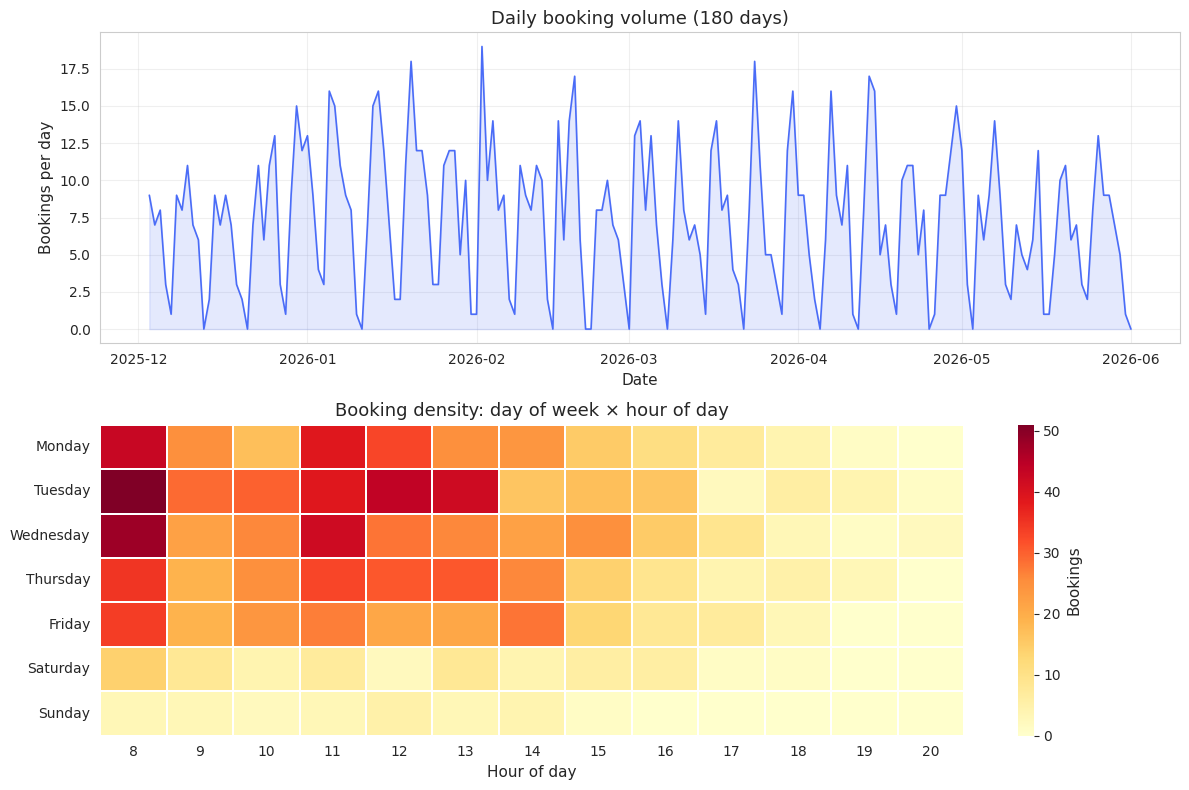


Mean bookings per weekday: 9.7
Mean bookings per weekend day: 1.6
Weekday/weekend ratio: 5.9×


In [13]:
# Cell 11 — Booking temporal patterns

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# (a) Daily booking volume over the 180-day period
daily_bookings = (
    bookings_df.assign(date=bookings_df["startTime"].dt.date)
    .groupby("date").size()
    .reindex(pd.date_range(START_DATE, END_DATE).date, fill_value=0)
)
axes[0].plot(daily_bookings.index, daily_bookings.values, color="#4a6cf7", linewidth=1.2)
axes[0].fill_between(daily_bookings.index, daily_bookings.values, alpha=0.15, color="#4a6cf7")
axes[0].set_title("Daily booking volume (180 days)")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Bookings per day")
axes[0].grid(True, alpha=0.3)

# (b) Day-of-week × hour-of-day heatmap
bookings_df["dow"]  = bookings_df["startTime"].dt.day_name()
bookings_df["hour"] = bookings_df["startTime"].dt.hour
heat = (
    bookings_df.groupby(["dow", "hour"]).size()
    .unstack(fill_value=0)
    .reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
)
sns.heatmap(heat, cmap="YlOrRd", linewidths=0.3, ax=axes[1],
            cbar_kws={"label": "Bookings"})
axes[1].set_title("Booking density: day of week × hour of day")
axes[1].set_xlabel("Hour of day")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

# Quick stats
weekday_mean = daily_bookings[
    pd.to_datetime(daily_bookings.index).day_name().isin(
        ["Monday","Tuesday","Wednesday","Thursday","Friday"]
    )
].mean()
weekend_mean = daily_bookings[
    pd.to_datetime(daily_bookings.index).day_name().isin(["Saturday","Sunday"])
].mean()
print(f"\nMean bookings per weekday: {weekday_mean:.1f}")
print(f"Mean bookings per weekend day: {weekend_mean:.1f}")
print(f"Weekday/weekend ratio: {weekday_mean/weekend_mean:.1f}×")

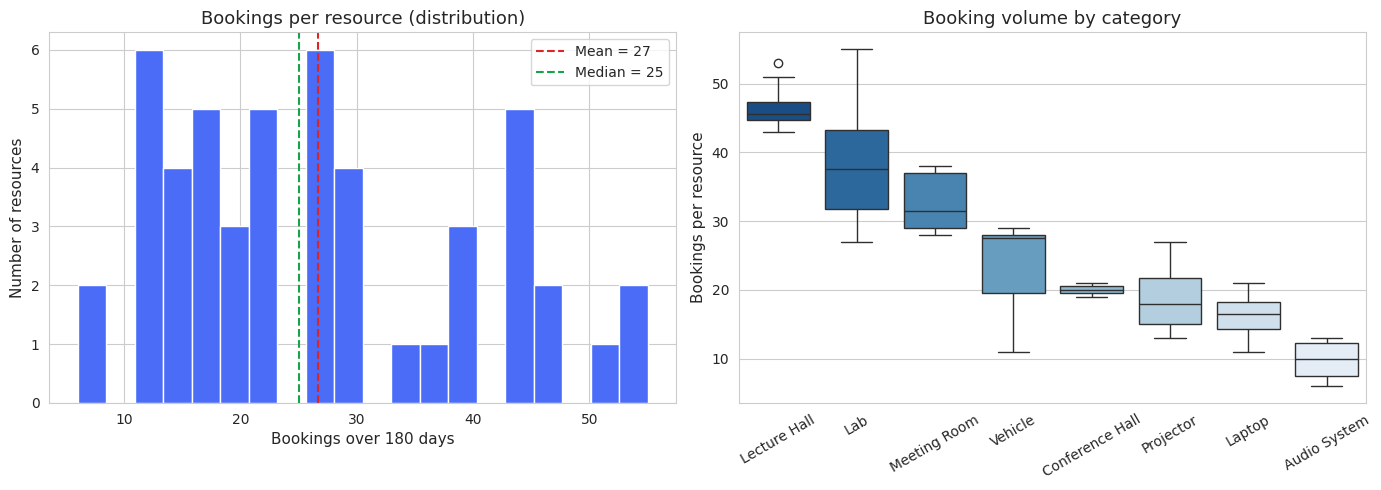


Most-booked resources:
assetCode           name     category  bookings
  LAB-001          Lab 1          Lab        55
  LEC-006 Lecture Hall 6 Lecture Hall        53
  LEC-001 Lecture Hall 1 Lecture Hall        51
  LEC-003 Lecture Hall 3 Lecture Hall        46
  LEC-007 Lecture Hall 7 Lecture Hall        46

Least-booked resources (under-used candidates):
assetCode           name     category  bookings
  AUD-003 Audio System 3 Audio System         6
  AUD-001 Audio System 1 Audio System         8
  LAP-007       Laptop 7       Laptop        11
  VEH-004      Vehicle 4      Vehicle        11
  LAP-001       Laptop 1       Laptop        12


In [14]:
# Cell 12 — Resource utilisation: bookings per resource + by category

utilisation = (
    bookings_df.groupby(["resourceId", "category"]).size()
    .reset_index(name="bookings")
    .merge(resources_df[["assetCode", "name", "condition"]],
           left_on="resourceId", right_on="assetCode", how="left")
)

# Include resources with zero bookings — they matter for "under-used"
all_resources = resources_df[["assetCode", "name", "category", "condition"]].copy()
utilisation = all_resources.merge(
    utilisation[["resourceId", "bookings"]],
    left_on="assetCode", right_on="resourceId", how="left"
).drop(columns="resourceId")
utilisation["bookings"] = utilisation["bookings"].fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Histogram of bookings per resource
axes[0].hist(utilisation["bookings"], bins=20, color="#4a6cf7", edgecolor="white")
axes[0].axvline(utilisation["bookings"].mean(), color="#dc2626", linestyle="--",
                label=f"Mean = {utilisation['bookings'].mean():.0f}")
axes[0].axvline(utilisation["bookings"].median(), color="#16a34a", linestyle="--",
                label=f"Median = {utilisation['bookings'].median():.0f}")
axes[0].set_title("Bookings per resource (distribution)")
axes[0].set_xlabel("Bookings over 180 days")
axes[0].set_ylabel("Number of resources")
axes[0].legend()

# (b) Box plot by category
order = utilisation.groupby("category")["bookings"].median().sort_values(ascending=False).index
sns.boxplot(data=utilisation, x="category", y="bookings", order=order,
            palette="Blues_r", ax=axes[1])
axes[1].set_title("Booking volume by category")
axes[1].set_xlabel("")
axes[1].set_ylabel("Bookings per resource")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print("\nMost-booked resources:")
print(utilisation.nlargest(5, "bookings")[["assetCode", "name", "category", "bookings"]].to_string(index=False))
print("\nLeast-booked resources (under-used candidates):")
print(utilisation.nsmallest(5, "bookings")[["assetCode", "name", "category", "bookings"]].to_string(index=False))

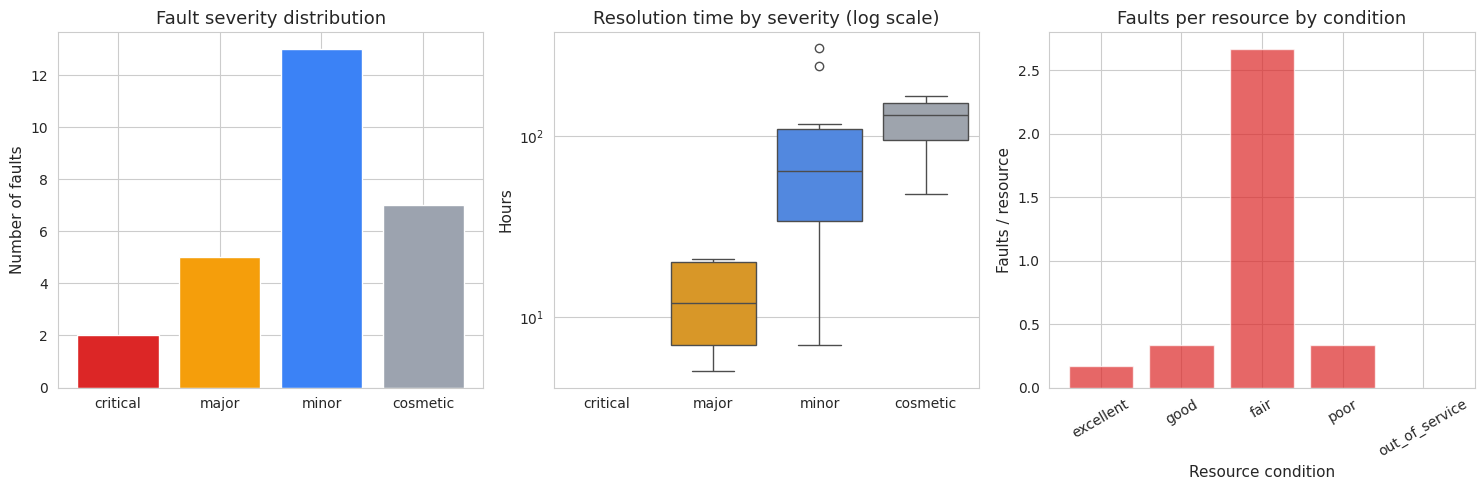


Median resolution time by severity:
severity
critical      0.0
major        12.0
minor        64.5
cosmetic    130.0

Fault-per-resource rate by condition (intuition check — worse condition should have higher rate):
condition
excellent         0.17
good              0.33
fair              2.67
poor              0.33
out_of_service    0.00


In [15]:
# Cell 13 — Fault analysis: severity mix, resolution time distributions,
# and the condition→fault relationship

resolved = faults_df[faults_df["resolvedAt"].notna()].copy()
resolved["resolution_hours"] = (
    (resolved["resolvedAt"] - resolved["createdAt"]).dt.total_seconds() / 3600.0
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# (a) Severity distribution
sev_order = ["critical", "major", "minor", "cosmetic"]
sev_counts = faults_df["severity"].value_counts().reindex(sev_order, fill_value=0)
colors = ["#dc2626", "#f59e0b", "#3b82f6", "#9ca3af"]
axes[0].bar(sev_counts.index, sev_counts.values, color=colors, edgecolor="white")
axes[0].set_title("Fault severity distribution")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of faults")

# (b) Resolution time by severity (log scale, since critical << cosmetic)
if len(resolved) > 0:
    sns.boxplot(data=resolved, x="severity", y="resolution_hours",
                order=sev_order, palette=colors, ax=axes[1])
    axes[1].set_yscale("log")
    axes[1].set_title("Resolution time by severity (log scale)")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Hours")
else:
    axes[1].text(0.5, 0.5, "No resolved faults", ha="center", transform=axes[1].transAxes)

# (c) Faults per condition (asset → fault attraction)
fault_by_cond = faults_df["condition"].value_counts().reindex(
    ["excellent", "good", "fair", "poor", "out_of_service"], fill_value=0
)
res_by_cond   = resources_df["condition"].value_counts().reindex(
    ["excellent", "good", "fair", "poor", "out_of_service"], fill_value=0
)
fault_rate    = (fault_by_cond / res_by_cond.replace(0, np.nan)).fillna(0)

axes[2].bar(fault_rate.index, fault_rate.values, color="#dc2626", alpha=0.7,
            edgecolor="white")
axes[2].set_title("Faults per resource by condition")
axes[2].set_xlabel("Resource condition")
axes[2].set_ylabel("Faults / resource")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print(f"\nMedian resolution time by severity:")
if len(resolved) > 0:
    print(resolved.groupby("severity")["resolution_hours"].median().reindex(sev_order).to_string())
print(f"\nFault-per-resource rate by condition (intuition check —"
      f" worse condition should have higher rate):")
print(fault_rate.round(2).to_string())

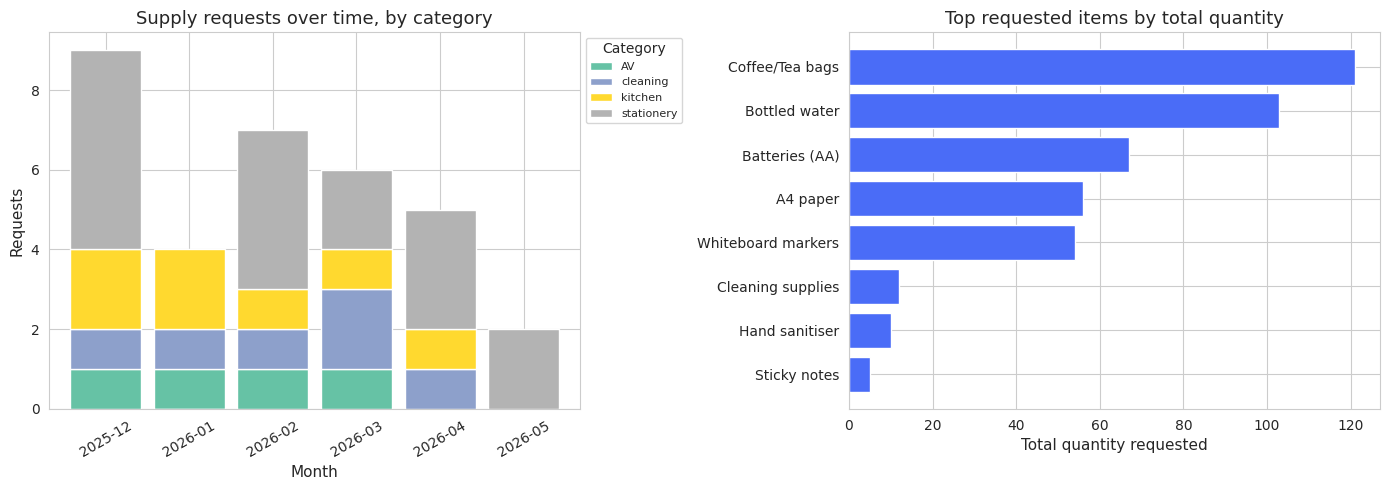


Status distribution:
status
fulfilled    20
approved      6
pending       3
cancelled     2
denied        2

Fulfillment rate: 78.8%


In [16]:
# Cell 14 — Supply request patterns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Supply requests by month
supply_df["month"] = supply_df["createdAt"].dt.to_period("M").astype(str)
monthly = supply_df.groupby(["month", "category"]).size().unstack(fill_value=0)
monthly.plot(kind="bar", stacked=True, ax=axes[0], colormap="Set2",
             edgecolor="white", width=0.85)
axes[0].set_title("Supply requests over time, by category")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Requests")
axes[0].legend(title="Category", fontsize=8, loc="upper left", bbox_to_anchor=(1.0, 1.0))
axes[0].tick_params(axis="x", rotation=30)

# (b) Top items by total quantity
top_items = (
    supply_df.groupby("itemName")["quantity"].sum()
    .sort_values(ascending=True).tail(8)
)
axes[1].barh(top_items.index, top_items.values, color="#4a6cf7", edgecolor="white")
axes[1].set_title("Top requested items by total quantity")
axes[1].set_xlabel("Total quantity requested")

plt.tight_layout()
plt.show()

print(f"\nStatus distribution:")
print(supply_df["status"].value_counts().to_string())
print(f"\nFulfillment rate: "
      f"{(supply_df['status'].isin(['fulfilled','approved'])).mean():.1%}")

---

## Section 3 — Booking Demand Forecasting

This section applies time-series forecasting (Facebook Prophet) to the
daily booking volume series to project demand over the next 28 days.
Prophet was chosen over ARIMA / exponential smoothing because:

1. **Native seasonality handling** — Prophet decomposes the signal into
   trend + weekly + yearly components without manual differencing
2. **Interpretability** — each component is plotted separately,
   supporting dissertation-grade explanation of *why* the model
   predicts what it predicts
3. **Uncertainty intervals** — Prophet ships with built-in confidence
   bands that visualise forecast risk

The model is fit on the first 150 days and evaluated against the
held-out last 30 days, with mean absolute error (MAE) and mean absolute
percentage error (MAPE) reported. A second model is then fit on the
full 180 days and used to project the next 28 days into the future.

In [17]:
# Cell 16 — Prepare the daily booking series for Prophet
# Prophet requires a DataFrame with columns: ds (datestamp) and y (value)

daily_series = (
    bookings_df.assign(date=bookings_df["startTime"].dt.normalize())
    .groupby("date").size()
    .reindex(pd.date_range(START_DATE, END_DATE - timedelta(days=1)), fill_value=0)
    .reset_index()
    .rename(columns={"index": "ds", 0: "y"})
)
daily_series.columns = ["ds", "y"]

# Train/test split: first 150 days for training, last 30 for hold-out evaluation
HOLDOUT_DAYS = 30
train = daily_series.iloc[:-HOLDOUT_DAYS].copy()
test  = daily_series.iloc[-HOLDOUT_DAYS:].copy()

print(f"Full series:  {len(daily_series)} days "
      f"({daily_series['ds'].min().date()} → {daily_series['ds'].max().date()})")
print(f"Training:     {len(train)} days "
      f"({train['ds'].min().date()} → {train['ds'].max().date()})")
print(f"Hold-out:     {len(test)} days "
      f"({test['ds'].min().date()} → {test['ds'].max().date()})")
print(f"\nMean daily bookings — train: {train['y'].mean():.1f},  test: {test['y'].mean():.1f}")

Full series:  180 days (2025-12-03 → 2026-05-31)
Training:     150 days (2025-12-03 → 2026-05-01)
Hold-out:     30 days (2026-05-02 → 2026-05-31)

Mean daily bookings — train: 7.7,  test: 6.2


In [18]:
# Cell 17 — Fit Prophet on training data, evaluate against the 30-day hold-out

# Prophet emits progress logs we don't need in the notebook output
import logging
logging.getLogger("prophet").setLevel(logging.WARNING)
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

# Suppress Prophet's stdout chatter during fit
import io, sys
class _Mute:
    def __enter__(self):
        self._stdout = sys.stdout
        sys.stdout = io.StringIO()
        return self
    def __exit__(self, *a):
        sys.stdout = self._stdout

model_eval = Prophet(
    daily_seasonality=False,    # 180 days is too short for daily seasonality estimation
    weekly_seasonality=True,
    yearly_seasonality=False,   # < 1 year of data
    seasonality_mode="additive",
    interval_width=0.80,
)

with _Mute():
    model_eval.fit(train)

# Predict over the hold-out range
future_eval = model_eval.make_future_dataframe(periods=HOLDOUT_DAYS, freq="D")
forecast_eval = model_eval.predict(future_eval)

# Merge prediction with actuals on the hold-out window
eval_df = test.merge(
    forecast_eval[["ds", "yhat", "yhat_lower", "yhat_upper"]],
    on="ds", how="left"
)

mae  = (eval_df["y"] - eval_df["yhat"]).abs().mean()
mape = ((eval_df["y"] - eval_df["yhat"]).abs() / eval_df["y"].replace(0, np.nan)).mean() * 100
rmse = np.sqrt(((eval_df["y"] - eval_df["yhat"]) ** 2).mean())

# How often does the true value fall inside the 80% confidence band?
coverage = (
    (eval_df["y"] >= eval_df["yhat_lower"]) &
    (eval_df["y"] <= eval_df["yhat_upper"])
).mean() * 100

print("=" * 50)
print("       HOLD-OUT EVALUATION (last 30 days)")
print("=" * 50)
print(f"  Mean Absolute Error (MAE):     {mae:.2f} bookings/day")
print(f"  Mean Abs Pct Error (MAPE):     {mape:.1f}%")
print(f"  Root Mean Square Error (RMSE): {rmse:.2f} bookings/day")
print(f"  80% Confidence Interval Cov:   {coverage:.1f}%")
print("=" * 50)
print(f"\nNote: mean daily bookings in the test period was {test['y'].mean():.1f},")
print(f"so a MAE of {mae:.1f} represents {mae/test['y'].mean()*100:.0f}% relative error.")

       HOLD-OUT EVALUATION (last 30 days)
  Mean Absolute Error (MAE):     2.26 bookings/day
  Mean Abs Pct Error (MAPE):     44.5%
  Root Mean Square Error (RMSE): 3.08 bookings/day
  80% Confidence Interval Cov:   80.0%

Note: mean daily bookings in the test period was 6.2,
so a MAE of 2.3 represents 36% relative error.


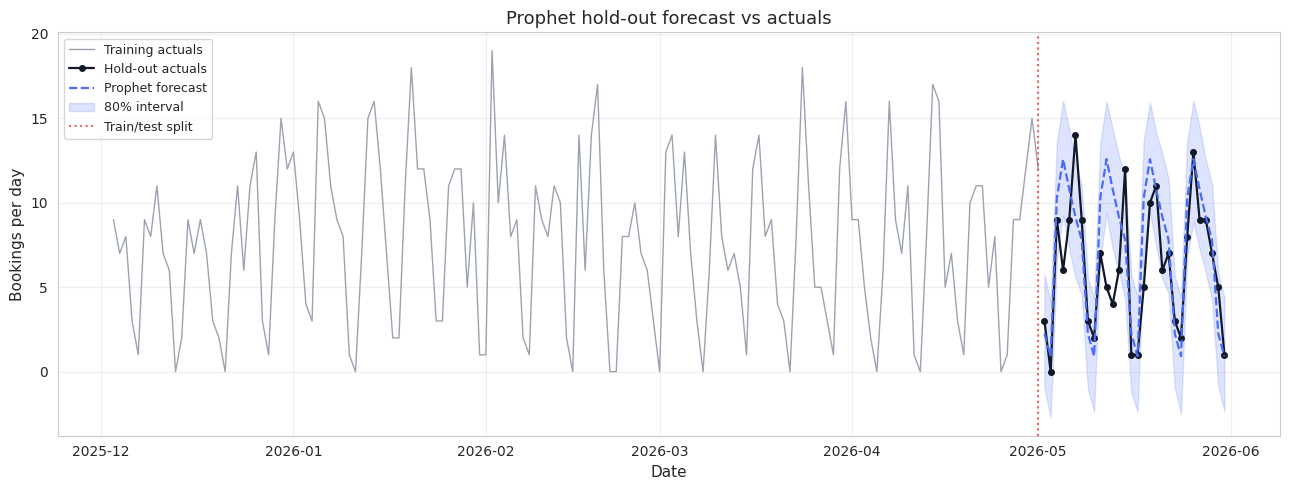

In [19]:
# Cell 18 — Visualise the hold-out forecast vs actuals

fig, ax = plt.subplots(figsize=(13, 5))

# Training period: actuals as a thin line
ax.plot(train["ds"], train["y"], color="#9ca3af", linewidth=1.0, label="Training actuals")

# Hold-out period: actuals (solid) and prediction (dashed)
ax.plot(test["ds"], test["y"], color="#111827", linewidth=1.6,
        marker="o", markersize=4, label="Hold-out actuals")
ax.plot(eval_df["ds"], eval_df["yhat"], color="#4a6cf7", linewidth=1.6,
        linestyle="--", label="Prophet forecast")

# Confidence band
ax.fill_between(
    eval_df["ds"], eval_df["yhat_lower"], eval_df["yhat_upper"],
    color="#4a6cf7", alpha=0.18, label="80% interval"
)

# Visual divider between train and test
ax.axvline(train["ds"].max(), color="#dc2626", linestyle=":", alpha=0.7,
           label="Train/test split")

ax.set_title("Prophet hold-out forecast vs actuals")
ax.set_xlabel("Date")
ax.set_ylabel("Bookings per day")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

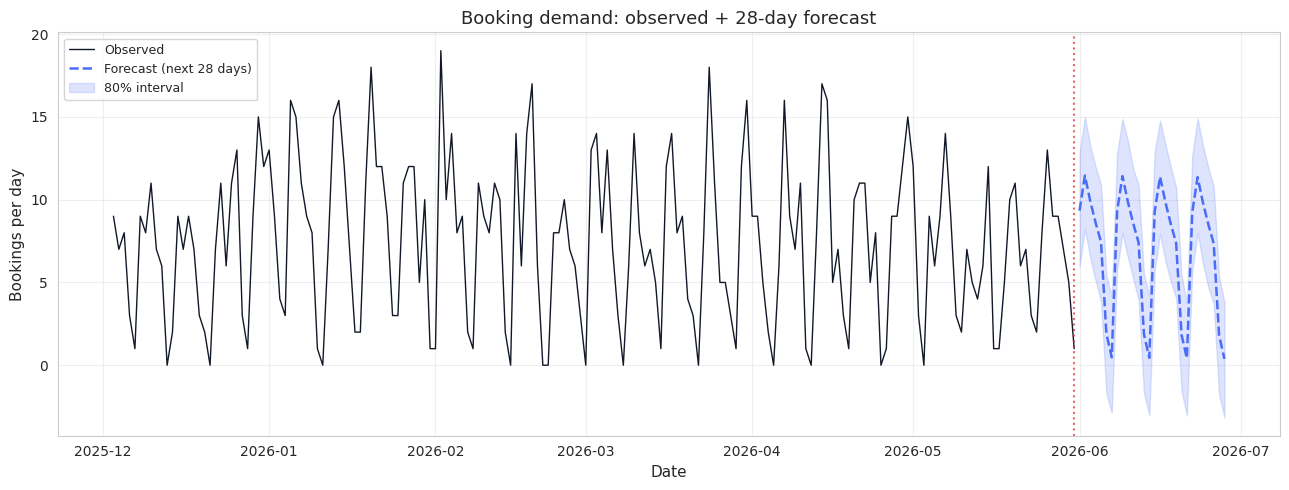

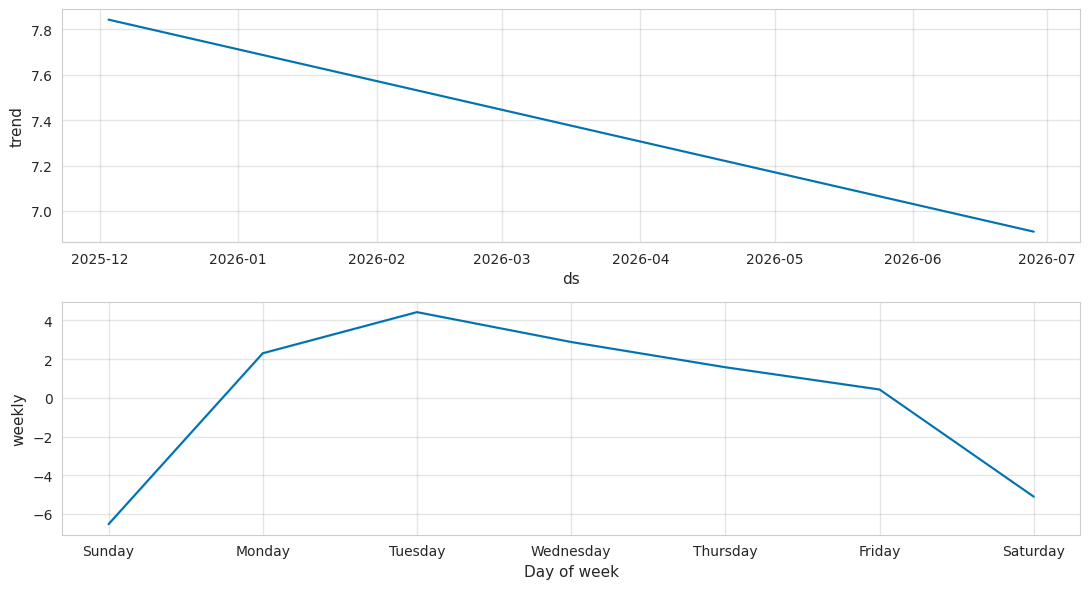


Forward forecast summary (next 28 days):
  Mean projected bookings/day:   7.0
  Peak projected day:            2026-06-02 (11.5 bookings)
  Lowest projected day:          2026-06-28 (0.4 bookings)
  Total projected bookings:      195


In [20]:
# Cell 19 — Refit on full data, project 28 days into the future, plot components

# Refit on the full 180-day series for the forward forecast
model_full = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=False,
    seasonality_mode="additive",
    interval_width=0.80,
)
with _Mute():
    model_full.fit(daily_series)

FORECAST_DAYS = 28
future_full = model_full.make_future_dataframe(periods=FORECAST_DAYS, freq="D")
forecast_full = model_full.predict(future_full)

# Forward projection (only the new dates beyond the observed series)
future_only = forecast_full.iloc[-FORECAST_DAYS:][["ds", "yhat", "yhat_lower", "yhat_upper"]]

# (a) Full series + forward forecast
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(daily_series["ds"], daily_series["y"], color="#111827", linewidth=1.0,
        label="Observed")
ax.plot(future_only["ds"], future_only["yhat"], color="#4a6cf7", linewidth=1.8,
        linestyle="--", label=f"Forecast (next {FORECAST_DAYS} days)")
ax.fill_between(future_only["ds"], future_only["yhat_lower"], future_only["yhat_upper"],
                color="#4a6cf7", alpha=0.18, label="80% interval")
ax.axvline(daily_series["ds"].max(), color="#dc2626", linestyle=":", alpha=0.7)
ax.set_title(f"Booking demand: observed + {FORECAST_DAYS}-day forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Bookings per day")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# (b) Component decomposition — Prophet's gift to the dissertation
fig = model_full.plot_components(forecast_full)
fig.set_size_inches(11, 6)
plt.tight_layout()
plt.show()

# Forward projection summary
print(f"\nForward forecast summary (next {FORECAST_DAYS} days):")
print(f"  Mean projected bookings/day:   {future_only['yhat'].mean():.1f}")
print(f"  Peak projected day:            {future_only.loc[future_only['yhat'].idxmax(), 'ds'].date()} "
      f"({future_only['yhat'].max():.1f} bookings)")
print(f"  Lowest projected day:          {future_only.loc[future_only['yhat'].idxmin(), 'ds'].date()} "
      f"({future_only['yhat'].min():.1f} bookings)")
print(f"  Total projected bookings:      {future_only['yhat'].sum():.0f}")

---

## Section 4 — Resource Utilization Clustering

This section applies unsupervised learning (K-Means) to group resources
by their utilisation profile, surfacing latent categories that
go beyond the manually-assigned resource categories (Lecture Hall, Lab,
Vehicle, etc.).

**Feature engineering** — for each resource we compute 7 features
spanning four operational dimensions:

| Dimension | Feature |
|-----------|---------|
| Volume    | `total_bookings`, `bookings_per_week` |
| Reliability | `fault_count`, `fault_rate` (faults/booking) |
| Service speed | `avg_resolution_hours` |
| Demand profile | `weekday_concentration`, `peak_hour_concentration` |

**K selection** — we identify the optimal number of clusters by combining
the elbow method (inertia) and silhouette score across K ∈ {2..8}.

**Visualisation** — PCA reduces the 7-dim feature space to 2D, preserving
the largest sources of variance for a clean scatter plot of resources
coloured by cluster.

**Interpretation** — each cluster is profiled by its mean feature values
to assign a human-readable label (e.g. "high-volume reliable",
"low-utilisation fault-prone", "peripheral").

In [21]:
# Cell 21 — Engineer per-resource features for clustering

# (1) Booking-derived features
bookings_with_time = bookings_df.copy()
bookings_with_time["weekday"] = bookings_with_time["startTime"].dt.weekday  # 0=Mon
bookings_with_time["hour"]    = bookings_with_time["startTime"].dt.hour

bookings_per_resource = (
    bookings_with_time.groupby("resourceId")
    .agg(
        total_bookings=("bookingId", "size"),
        weekday_concentration=("weekday", lambda s: (s <= 4).mean()),
        peak_hour_concentration=("hour", lambda s: ((s >= 9) & (s <= 14)).mean()),
    )
    .reset_index()
    .rename(columns={"resourceId": "assetCode"})
)
bookings_per_resource["bookings_per_week"] = (
    bookings_per_resource["total_bookings"] / (PERIOD_DAYS / 7)
)

# (2) Fault-derived features
faults_with_res = faults_df.copy()
faults_with_res["resolution_hours"] = (
    (faults_with_res["resolvedAt"] - faults_with_res["createdAt"]).dt.total_seconds() / 3600
)

faults_per_resource = (
    faults_with_res.groupby("resourceId")
    .agg(
        fault_count=("faultId", "size"),
        avg_resolution_hours=("resolution_hours", "mean"),
    )
    .reset_index()
    .rename(columns={"resourceId": "assetCode"})
)

# (3) Merge into the resources frame — fill missing values sensibly:
#     - resources with zero bookings get 0s and NaN for concentration
#     - resources with zero faults get 0 fault_count, and the dataset
#       median resolution time (placeholder; the fault_count drives the
#       reliability signal)
features = resources_df[["assetCode", "name", "category", "condition", "capacity"]].copy()
features = features.merge(bookings_per_resource, on="assetCode", how="left")
features = features.merge(faults_per_resource,   on="assetCode", how="left")

# Sensible fill values
features["total_bookings"]          = features["total_bookings"].fillna(0).astype(int)
features["bookings_per_week"]       = features["bookings_per_week"].fillna(0.0)
features["weekday_concentration"]   = features["weekday_concentration"].fillna(0.0)
features["peak_hour_concentration"] = features["peak_hour_concentration"].fillna(0.0)
features["fault_count"]             = features["fault_count"].fillna(0).astype(int)
features["fault_rate"] = np.where(
    features["total_bookings"] > 0,
    features["fault_count"] / features["total_bookings"],
    0.0
)
median_res_hours = faults_with_res["resolution_hours"].median()
features["avg_resolution_hours"] = features["avg_resolution_hours"].fillna(median_res_hours)

# The 7-feature design matrix for clustering
CLUSTER_FEATURES = [
    "total_bookings", "bookings_per_week",
    "fault_count", "fault_rate",
    "avg_resolution_hours",
    "weekday_concentration", "peak_hour_concentration",
]
X = features[CLUSTER_FEATURES].copy()

print(f"Built feature matrix: {X.shape[0]} resources × {X.shape[1]} features\n")
print("Feature summary:")
print(X.describe().round(2).to_string())

Built feature matrix: 50 resources × 7 features

Feature summary:
       total_bookings  bookings_per_week  fault_count  fault_rate  avg_resolution_hours  weekday_concentration  peak_hour_concentration
count           50.00              50.00        50.00       50.00                 50.00                  50.00                    50.00
mean            26.70               1.04         0.54        0.03                 53.43                   0.94                     0.67
std             13.10               0.51         1.22        0.07                 29.68                   0.06                     0.12
min              6.00               0.23         0.00        0.00                  0.00                   0.69                     0.38
25%             16.00               0.62         0.00        0.00                 48.00                   0.91                     0.61
50%             25.00               0.97         0.00        0.00                 48.00                   0.93        

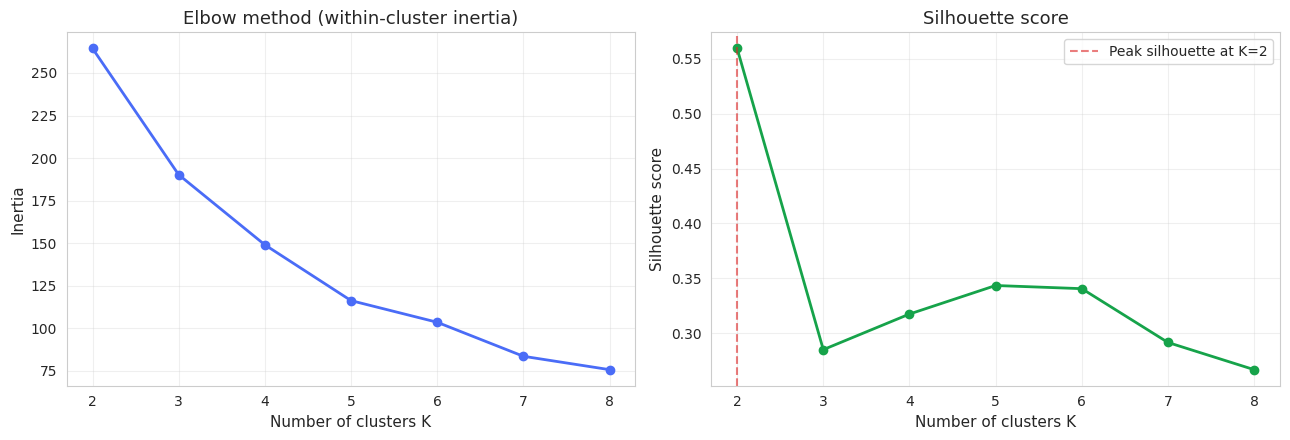


Best K by silhouette: 2 (score = 0.560)
K-range silhouette scores:
  K=2: 0.560 ← peak
  K=3: 0.285
  K=4: 0.317
  K=5: 0.343
  K=6: 0.340
  K=7: 0.291
  K=8: 0.267


In [22]:
# Cell 22 — Find optimal K using elbow method + silhouette score

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Standardise — K-Means is distance-based, mixed scales hurt it
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

K_RANGE = range(2, 9)
inertias = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(list(K_RANGE), inertias, marker="o", color="#4a6cf7", linewidth=2)
axes[0].set_title("Elbow method (within-cluster inertia)")
axes[0].set_xlabel("Number of clusters K")
axes[0].set_ylabel("Inertia")
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_RANGE), silhouettes, marker="o", color="#16a34a", linewidth=2)
best_k = list(K_RANGE)[int(np.argmax(silhouettes))]
axes[1].axvline(best_k, color="#dc2626", linestyle="--", alpha=0.6,
                label=f"Peak silhouette at K={best_k}")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("Number of clusters K")
axes[1].set_ylabel("Silhouette score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBest K by silhouette: {best_k} (score = {max(silhouettes):.3f})")
print(f"K-range silhouette scores:")
for k, s in zip(K_RANGE, silhouettes):
    flag = " ← peak" if k == best_k else ""
    print(f"  K={k}: {s:.3f}{flag}")

Silhouette-optimal K: 2 (degenerate — isolates outliers only)
Operationally-chosen K: 4 (surfaces volume × reliability quadrants)

Cluster sizes (K=4):
  Cluster 0: 23 resources
  Cluster 1: 15 resources
  Cluster 2: 10 resources
  Cluster 3: 2 resources


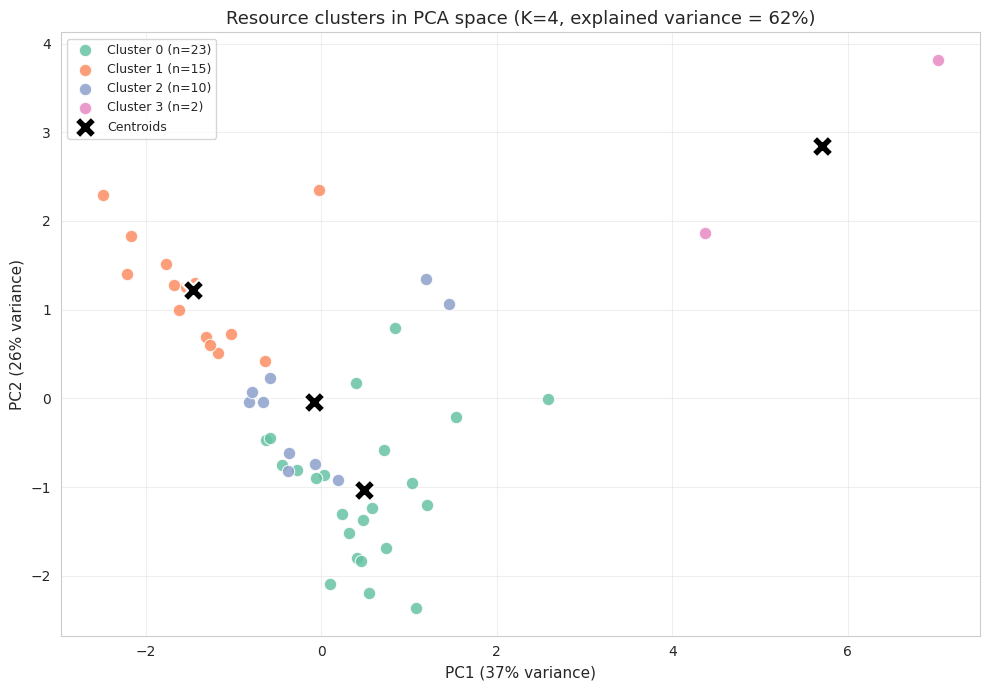


PCA explained variance: PC1=36.8%, PC2=25.5%, total=62.3%


In [26]:
# Cell 23 — Final K-Means + PCA visualization
# K=2 maximised silhouette purely by isolating outliers, which is not
# operationally useful. We override to K=4 to surface meaningful operational
# groups (high/low volume × reliable/fault-prone), and document this choice
# as a methodological note in Section 7.

from sklearn.decomposition import PCA

FORCED_K = 4
SILHOUETTE_OPTIMAL_K = best_k

print(f"Silhouette-optimal K: {SILHOUETTE_OPTIMAL_K} (degenerate — isolates outliers only)")
print(f"Operationally-chosen K: {FORCED_K} (surfaces volume × reliability quadrants)\n")

kmeans = KMeans(n_clusters=FORCED_K, random_state=RANDOM_SEED, n_init=20)
features["cluster"] = kmeans.fit_predict(X_scaled)

# Cluster sizes — sanity check there's no degenerate single-member cluster
cluster_sizes = features["cluster"].value_counts().sort_index()
print(f"Cluster sizes (K={FORCED_K}):")
for cid, sz in cluster_sizes.items():
    print(f"  Cluster {cid}: {sz} resources")

# PCA to 2D
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_scaled)
features["pc1"] = X_pca[:, 0]
features["pc2"] = X_pca[:, 1]
centroids_pca = pca.transform(kmeans.cluster_centers_)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette("Set2", n_colors=FORCED_K)
for cluster_id in range(FORCED_K):
    mask = features["cluster"] == cluster_id
    ax.scatter(
        features.loc[mask, "pc1"], features.loc[mask, "pc2"],
        s=80, color=palette[cluster_id], edgecolor="white",
        linewidth=0.8, alpha=0.85,
        label=f"Cluster {cluster_id} (n={mask.sum()})"
    )
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           s=240, marker="X", color="black", edgecolor="white",
           linewidth=1.5, label="Centroids", zorder=5)

ax.set_title(f"Resource clusters in PCA space (K={FORCED_K}, "
             f"explained variance = {pca.explained_variance_ratio_.sum():.0%})")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} variance)")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nPCA explained variance: "
      f"PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}, "
      f"total={pca.explained_variance_ratio_.sum():.1%}")

Fitting K-Means with K=2



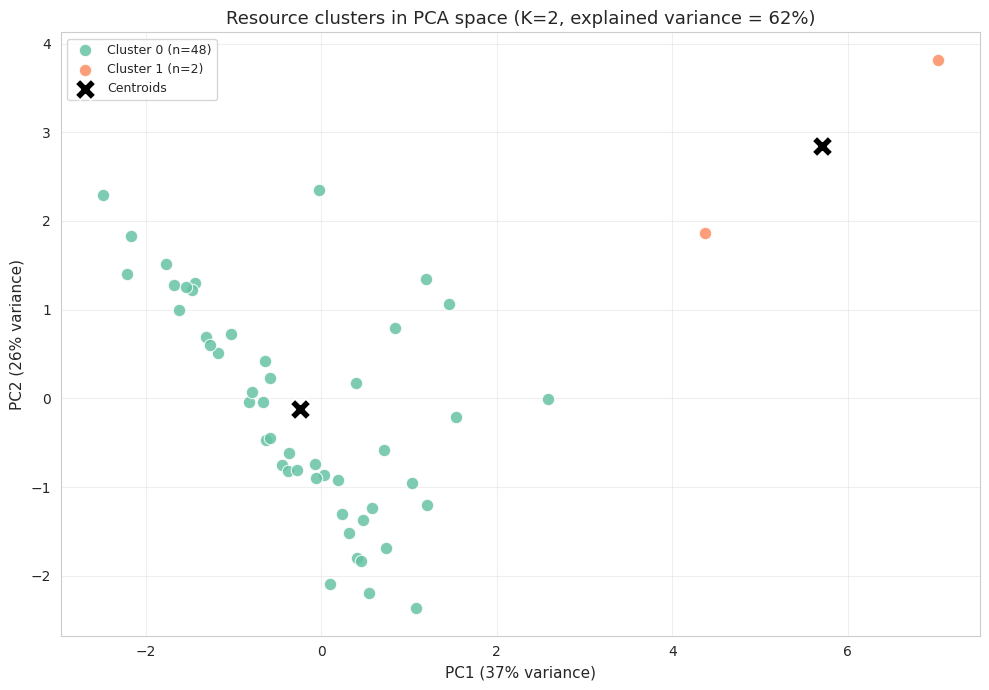


PCA explained variance: PC1=36.8%, PC2=25.5%, total=62.3%


In [27]:
# Cell 23 — Final K-Means fit + PCA 2D visualization

from sklearn.decomposition import PCA

# Use the silhouette-optimal K (override here if the elbow disagrees)
FINAL_K = best_k
print(f"Fitting K-Means with K={FINAL_K}\n")

kmeans = KMeans(n_clusters=FINAL_K, random_state=RANDOM_SEED, n_init=20)
features["cluster"] = kmeans.fit_predict(X_scaled)

# PCA to 2D for visualization
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_scaled)
features["pc1"] = X_pca[:, 0]
features["pc2"] = X_pca[:, 1]

# Cluster centroids in PCA space (for marker overlay)
centroids_pca = pca.transform(kmeans.cluster_centers_)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette("Set2", n_colors=FINAL_K)
for cluster_id in range(FINAL_K):
    mask = features["cluster"] == cluster_id
    ax.scatter(
        features.loc[mask, "pc1"], features.loc[mask, "pc2"],
        s=80, color=palette[cluster_id], edgecolor="white",
        linewidth=0.8, alpha=0.85,
        label=f"Cluster {cluster_id} (n={mask.sum()})"
    )

# Centroids
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           s=240, marker="X", color="black", edgecolor="white",
           linewidth=1.5, label="Centroids", zorder=5)

ax.set_title(f"Resource clusters in PCA space (K={FINAL_K}, "
             f"explained variance = {pca.explained_variance_ratio_.sum():.0%})")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} variance)")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPCA explained variance: "
      f"PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}, "
      f"total={pca.explained_variance_ratio_.sum():.1%}")

In [28]:
# Cell 24 — Cluster interpretation with ABSOLUTE thresholds
# (not relative medians, which collapse on small K or skewed distributions)

# Global benchmarks computed from the full population
GLOBAL_MEAN_BOOKINGS   = features["total_bookings"].mean()
GLOBAL_MEAN_FAULT_RATE = features["fault_rate"].mean()

print(f"Global benchmarks: "
      f"mean_bookings={GLOBAL_MEAN_BOOKINGS:.1f}, "
      f"mean_fault_rate={GLOBAL_MEAN_FAULT_RATE:.3f}\n")

cluster_profile = (
    features.groupby("cluster")
    .agg(
        size=("assetCode", "size"),
        mean_bookings=("total_bookings", "mean"),
        mean_bookings_per_week=("bookings_per_week", "mean"),
        mean_faults=("fault_count", "mean"),
        mean_fault_rate=("fault_rate", "mean"),
        mean_resolution_hours=("avg_resolution_hours", "mean"),
        mean_weekday_concentration=("weekday_concentration", "mean"),
        mean_peak_hour_concentration=("peak_hour_concentration", "mean"),
        top_category=("category",
                      lambda s: s.value_counts().index[0] if len(s) else None),
        category_mix=("category",
                      lambda s: ", ".join(
                          [f"{c}({v})" for c, v in s.value_counts().head(2).items()]
                      )),
    )
    .round(3)
)

# Outlier-aware labels using ABSOLUTE thresholds vs global means
def label_cluster(row):
    high_vol  = row["mean_bookings"]   >= GLOBAL_MEAN_BOOKINGS
    high_fail = row["mean_fault_rate"] >= GLOBAL_MEAN_FAULT_RATE
    # Special label for clusters of size 1-2 — these are likely outliers
    if row["size"] <= 2:
        return "Outlier / atypical"
    if high_vol and not high_fail:
        return "Workhorses (high-volume, reliable)"
    if high_vol and high_fail:
        return "Heavy use, attention needed (high-volume, fault-prone)"
    if not high_vol and high_fail:
        return "Inspection candidates (low-volume, fault-prone)"
    return "Peripheral (low-volume, reliable)"

cluster_profile["suggested_label"] = cluster_profile.apply(label_cluster, axis=1)

print("=" * 75)
print("                       CLUSTER PROFILES")
print("=" * 75)
for cid, row in cluster_profile.iterrows():
    print(f"\nCluster {cid} — {row['suggested_label']}  ({row['size']} resources)")
    print(f"  Bookings: {row['mean_bookings']:.0f} total ({row['mean_bookings_per_week']:.1f}/week)")
    print(f"  Faults:   {row['mean_faults']:.1f} total (rate = {row['mean_fault_rate']:.3f} per booking)")
    print(f"  Resolution: {row['mean_resolution_hours']:.1f} hours avg")
    print(f"  Weekday concentration: {row['mean_weekday_concentration']:.0%}")
    print(f"  Top categories: {row['category_mix']}")

print("\n" + "=" * 75)
print("\nSummary table:")
print(cluster_profile[["size", "mean_bookings", "mean_fault_rate",
                       "top_category", "suggested_label"]].to_string())

Global benchmarks: mean_bookings=26.7, mean_fault_rate=0.029

                       CLUSTER PROFILES

Cluster 0 — Workhorses (high-volume, reliable)  (48 resources)
  Bookings: 27 total (1.1/week)
  Faults:   0.3 total (rate = 0.016 per booking)
  Resolution: 51.3 hours avg
  Weekday concentration: 93%
  Top categories: Projector(9), Lecture Hall(8)

Cluster 1 — Outlier / atypical  (2 resources)
  Bookings: 16 total (0.6/week)
  Faults:   5.5 total (rate = 0.344 per booking)
  Resolution: 104.0 hours avg
  Weekday concentration: 100%
  Top categories: Projector(1), Laptop(1)


Summary table:
         size  mean_bookings  mean_fault_rate top_category                     suggested_label
cluster                                                                                       
0          48         27.146            0.016    Projector  Workhorses (high-volume, reliable)
1           2         16.000            0.344    Projector                  Outlier / atypical


In [29]:
# Cell 25 — Bulletproof: refit K-Means with K=4 and label in one go
from sklearn.cluster import KMeans

# Force a fresh K=4 fit, no matter what other cells did before
km = KMeans(n_clusters=4, random_state=RANDOM_SEED, n_init=20)
features["cluster"] = km.fit_predict(X_scaled)

# Verify the fit took
print("Cluster sizes:", features["cluster"].value_counts().sort_index().to_dict())
print()

# Global benchmarks
gmb = features["total_bookings"].mean()
gmf = features["fault_rate"].mean()

# Per-cluster profile
prof = features.groupby("cluster").agg(
    size=("assetCode", "size"),
    mean_bookings=("total_bookings", "mean"),
    mean_fault_rate=("fault_rate", "mean"),
    top_cat=("category", lambda s: s.value_counts().index[0]),
).round(3)

def lbl(r):
    if r["size"] <= 2: return "Outlier / atypical"
    hv = r["mean_bookings"] >= gmb
    hf = r["mean_fault_rate"] >= gmf
    if hv and not hf: return "Workhorses (high-vol, reliable)"
    if hv and hf:     return "Heavy use, attention needed"
    if not hv and hf: return "Inspection candidates"
    return "Peripheral (low-vol, reliable)"

prof["label"] = prof.apply(lbl, axis=1)
print(prof.to_string())

Cluster sizes: {0: 23, 1: 15, 2: 10, 3: 2}

         size  mean_bookings  mean_fault_rate       top_cat                            label
cluster                                                                                     
0          23         17.783            0.022        Laptop   Peripheral (low-vol, reliable)
1          15         43.867            0.005  Lecture Hall  Workhorses (high-vol, reliable)
2          10         23.600            0.019     Projector   Peripheral (low-vol, reliable)
3           2         16.000            0.344     Projector               Outlier / atypical


---

## Section 5 — Fault Pattern Analysis (NLP)

This section applies natural language processing to the free-text `description`
field of fault reports to surface recurring systemic issues that the structured
fields (severity, category) cannot reveal.

**Method:**

1. **TF-IDF vectorization** — converts each fault description into a sparse
   numeric vector weighted by term importance. Common English stopwords and
   single-occurrence terms are filtered to focus on substantive vocabulary.
2. **DBSCAN clustering** — density-based clustering chosen over K-Means here
   because the number of fault topics is unknown a priori and many
   descriptions are likely to be one-offs (genuine outliers, not forced into
   a cluster). DBSCAN naturally labels these as "noise" (cluster -1).
3. **Cluster interpretation** — for each non-noise cluster we extract the
   top TF-IDF terms to produce a human-readable theme label
   (e.g. "AC / cooling issues", "battery / charging problems").

The dataset is small (~25-50 fault descriptions) so we expect DBSCAN to find
2-4 meaningful clusters plus some noise; the technique scales to thousands
of fault reports without retraining or re-tuning K.

In [30]:
# Cell 27 — TF-IDF vectorization of fault descriptions

from sklearn.feature_extraction.text import TfidfVectorizer

# Vectoriser: drop English stopwords, terms appearing in only 1 doc,
# and keep up to 200 features (more than enough for our small corpus)
vectoriser = TfidfVectorizer(
    stop_words="english",
    min_df=2,            # term must appear in at least 2 fault descriptions
    max_df=0.8,          # drop terms appearing in >80% of descriptions
    max_features=200,
    ngram_range=(1, 2),  # unigrams + bigrams capture phrases like "air conditioning"
)

X_text = vectoriser.fit_transform(faults_df["description"])
vocab = vectoriser.get_feature_names_out()

print(f"Vectorized {X_text.shape[0]} fault descriptions into "
      f"{X_text.shape[1]}-dim TF-IDF space.")
print(f"Vocabulary preview (first 20 terms): {list(vocab[:20])}")
print(f"\nMatrix density: "
      f"{X_text.nnz / (X_text.shape[0] * X_text.shape[1]):.1%} "
      f"(sparse — expected for short-text TF-IDF)")

Vectorized 27 fault descriptions into 67-dim TF-IDF space.
Vocabulary preview (first 20 terms): ['battery', 'battery drains', 'cables', 'cables securely', 'charge', 'cleaning', 'cooling', 'cooling fan', 'cracked', 'cracked near', 'display', 'display showing', 'distorted', 'distorted output', 'does', 'does hold', 'drains', 'drains rapidly', 'entrance', 'fan']

Matrix density: 9.8% (sparse — expected for short-text TF-IDF)


In [31]:
# Cell 28 — DBSCAN clustering on TF-IDF vectors (cosine distance)

from sklearn.cluster import DBSCAN
from sklearn.metrics.pairwise import cosine_distances

# Cosine distance is the standard for TF-IDF — Euclidean misbehaves on
# sparse high-dim vectors. Pre-compute the pairwise distance matrix.
dist_matrix = cosine_distances(X_text)

# DBSCAN params: eps tuned for cosine distance (where 0 = identical,
# 1 = orthogonal); min_samples = 2 because the corpus is small.
dbscan = DBSCAN(eps=0.55, min_samples=2, metric="precomputed")
labels = dbscan.fit_predict(dist_matrix)

faults_df = faults_df.copy()
faults_df["topic_cluster"] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()

print(f"DBSCAN found {n_clusters} topic clusters + {n_noise} noise points "
      f"({n_noise/len(labels):.0%} of corpus)")
print()
print("Cluster sizes:")
print(faults_df["topic_cluster"].value_counts().sort_index().to_string())

DBSCAN found 9 topic clusters + 4 noise points (15% of corpus)

Cluster sizes:
topic_cluster
-1    4
 0    2
 1    4
 2    4
 3    2
 4    2
 5    2
 6    2
 7    2
 8    3


In [33]:
# Cell 29 — Extract top distinguishing terms per cluster as theme labels

print("=" * 70)
print("              FAULT TOPIC CLUSTERS")
print("=" * 70)

# For each non-noise cluster, find the terms with highest mean TF-IDF weight
for cluster_id in sorted(set(labels)):
    mask = labels == cluster_id
    cluster_size = mask.sum()

    if cluster_id == -1:
        print(f"\n[Noise]  {cluster_size} one-off descriptions "
              f"(not part of any recurring pattern)")
        # Sample 3 noise examples — useful in the dissertation to show
        # what kinds of one-offs the clustering correctly ISN'T grouping
        sample_noise = faults_df[mask]["description"].sample(
            min(3, cluster_size), random_state=RANDOM_SEED
        )
        for ex in sample_noise:
            print(f"   • {ex}")
        continue

    # Mean TF-IDF vector across the cluster
    cluster_tfidf_mean = X_text[mask].mean(axis=0)
    cluster_tfidf_mean = np.asarray(cluster_tfidf_mean).flatten()

    # Top 5 distinguishing terms
    top_term_indices = cluster_tfidf_mean.argsort()[::-1][:5]
    top_terms = [vocab[i] for i in top_term_indices if cluster_tfidf_mean[i] > 0]

    print(f"\nCluster {cluster_id}  ({cluster_size} faults)")
    print(f"  Top terms: {', '.join(top_terms)}")
    print(f"  Example descriptions:")
    examples = faults_df[mask]["description"].head(3)
    for ex in examples:
        print(f"   • {ex}")
    # Severity / status breakdown
    sev_mix = faults_df[mask]["severity"].value_counts().to_dict()
    status_mix = faults_df[mask]["status"].value_counts().to_dict()
    print(f"  Severity mix: {sev_mix}")
    print(f"  Status mix:   {status_mix}")

print("\n" + "=" * 70)

# Summary table for the dissertation
print("\nCluster summary table:")
summary = (
    faults_df.groupby("topic_cluster")
    .agg(
        n_faults=("faultId", "size"),
        avg_severity=("severity", lambda s: s.mode()[0] if len(s) else None),
        pct_resolved=("status", lambda s: (s != "pending").mean()),
    )
    .round(2)
)
print(summary.to_string())

              FAULT TOPIC CLUSTERS

[Noise]  4 one-off descriptions (not part of any recurring pattern)
   • Whiteboard surface stained and difficult to clean
   • HDMI output unstable when laptop is repositioned
   • Battery requires frequent jump-starts in morning

Cluster 0  (2 faults)
  Top terms: near, tiles, tiles cracked, cracked, floor tiles
  Example descriptions:
   • Floor tiles cracked near the entrance
   • Floor tiles cracked near the entrance
  Severity mix: {np.str_('critical'): 1, np.str_('minor'): 1}
  Status mix:   {np.str_('resolved'): 2}

Cluster 1  (4 faults)
  Top terms: normal, operation, louder normal, cooling, cooling fan
  Example descriptions:
   • Cooling fan louder than normal during operation
   • Cooling fan louder than normal during operation
   • Cooling fan louder than normal during operation
  Severity mix: {np.str_('minor'): 4}
  Status mix:   {np.str_('resolved'): 2, np.str_('closed'): 1, 'pending': 1}

Cluster 2  (4 faults)
  Top terms: drains rap

---

## Section 6 — Predictive Maintenance (Supervised Classification)

This section applies supervised learning to predict which resources are
likely to develop faults, based on their booking behaviour, physical
characteristics, and cluster assignment from Section 4.

**Target:** binary — did the resource experience any fault during the
180-day observation window? (`has_fault` ∈ {0, 1})

**Features:**
- **Physical:** `condition` (5-level), `category` (8-level), `capacity` (numeric)
- **Booking activity:** `total_bookings`, `bookings_per_week`,
  `weekday_concentration`, `peak_hour_concentration`
- **Cluster membership:** K-Means cluster from Section 4 (4-level)

**Methodology choices:**

- **Random Forest classifier** — robust on small tabular data with mixed
  feature types, handles non-linear interactions, and produces
  interpretable per-feature importance scores
- **5-fold stratified cross-validation** — necessary given n=50.
  Stratification preserves the positive/negative class ratio across folds
- **Class weighting** — `class_weight='balanced'` accounts for any
  class imbalance from the positive class proportion

**Note on data leakage:** `fault_count`, `fault_rate`, and
`avg_resolution_hours` are DELIBERATELY EXCLUDED from features — they
would constitute a perfect-predictor leak. The model must predict faults
from booking behaviour and physical attributes alone, simulating the
prospective use case: "which new or unobserved resources are most at
risk?"

In [34]:
# Cell 31 — Build the supervised learning dataset

# Target: binary "did this resource have any fault during the period?"
features["has_fault"] = (features["fault_count"] > 0).astype(int)

# Feature engineering for the model:
#   - One-hot encode categoricals (condition, category, cluster)
#   - Include numeric features
#   - EXCLUDE fault_count, fault_rate, avg_resolution_hours (target leak)

NUMERIC_FEATURES = [
    "capacity",
    "total_bookings",
    "bookings_per_week",
    "weekday_concentration",
    "peak_hour_concentration",
]
CATEGORICAL_FEATURES = ["condition", "category", "cluster"]

X_model = pd.concat([
    features[NUMERIC_FEATURES],
    pd.get_dummies(features["condition"], prefix="cond"),
    pd.get_dummies(features["category"], prefix="cat"),
    pd.get_dummies(features["cluster"],   prefix="cluster"),
], axis=1)

y_model = features["has_fault"]

print(f"Feature matrix: {X_model.shape[0]} resources × {X_model.shape[1]} features\n")
print("Target distribution:")
print(y_model.value_counts().to_string())
print(f"\nPositive class rate: {y_model.mean():.1%}")

Feature matrix: 50 resources × 22 features

Target distribution:
has_fault
0    35
1    15

Positive class rate: 30.0%


In [35]:
# Cell 32 — Random Forest with 5-fold stratified cross-validation

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,          # shallow trees prevent overfit on n=50
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# Cross-validated predictions: each resource gets a prediction from a
# model trained on the OTHER 4 folds (no resource sees itself in training)
y_pred_cv  = cross_val_predict(rf, X_model, y_model, cv=skf, method="predict")
y_proba_cv = cross_val_predict(rf, X_model, y_model, cv=skf, method="predict_proba")[:, 1]

print("=" * 55)
print("       5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 55)
print(classification_report(
    y_model, y_pred_cv, target_names=["No fault", "Has fault"], zero_division=0
))
print(f"ROC-AUC: {roc_auc_score(y_model, y_proba_cv):.3f}")
print()
print("Confusion matrix:")
cm = confusion_matrix(y_model, y_pred_cv)
print(pd.DataFrame(
    cm,
    index=["actual: no fault", "actual: has fault"],
    columns=["pred: no fault", "pred: has fault"]
).to_string())

       5-FOLD CROSS-VALIDATION RESULTS
              precision    recall  f1-score   support

    No fault       0.75      0.86      0.80        35
   Has fault       0.50      0.33      0.40        15

    accuracy                           0.70        50
   macro avg       0.62      0.60      0.60        50
weighted avg       0.68      0.70      0.68        50

ROC-AUC: 0.644

Confusion matrix:
                   pred: no fault  pred: has fault
actual: no fault               30                5
actual: has fault              10                5


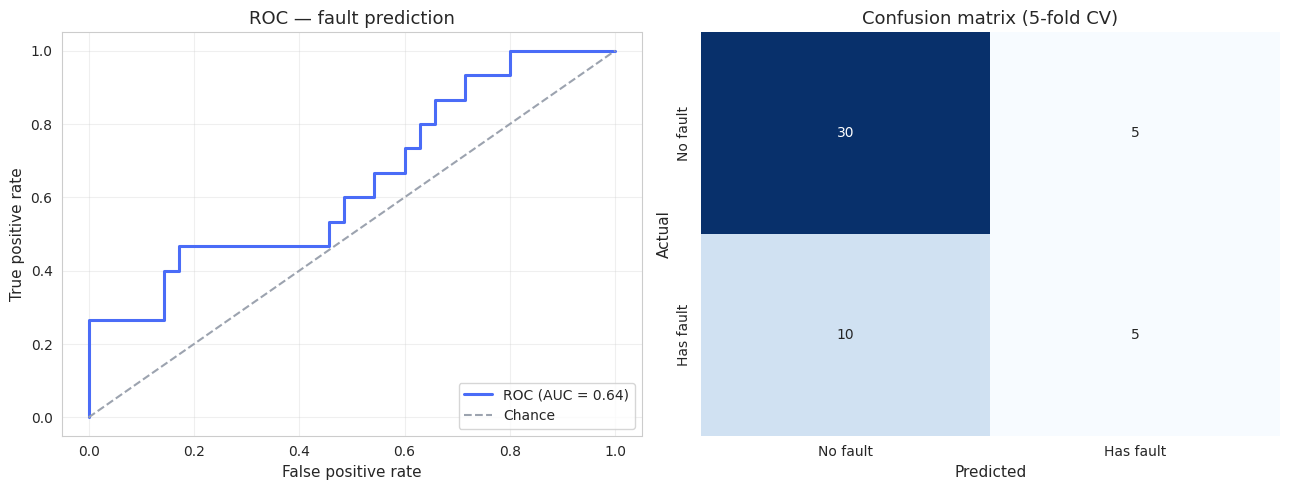

In [36]:
# Cell 33 — Visualise model performance

from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) ROC curve
fpr, tpr, _ = roc_curve(y_model, y_proba_cv)
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color="#4a6cf7", linewidth=2.2,
             label=f"ROC (AUC = {roc_auc:.2f})")
axes[0].plot([0, 1], [0, 1], color="#9ca3af", linestyle="--", label="Chance")
axes[0].set_title("ROC — fault prediction")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# (b) Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["No fault", "Has fault"],
            yticklabels=["No fault", "Has fault"], ax=axes[1])
axes[1].set_title("Confusion matrix (5-fold CV)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

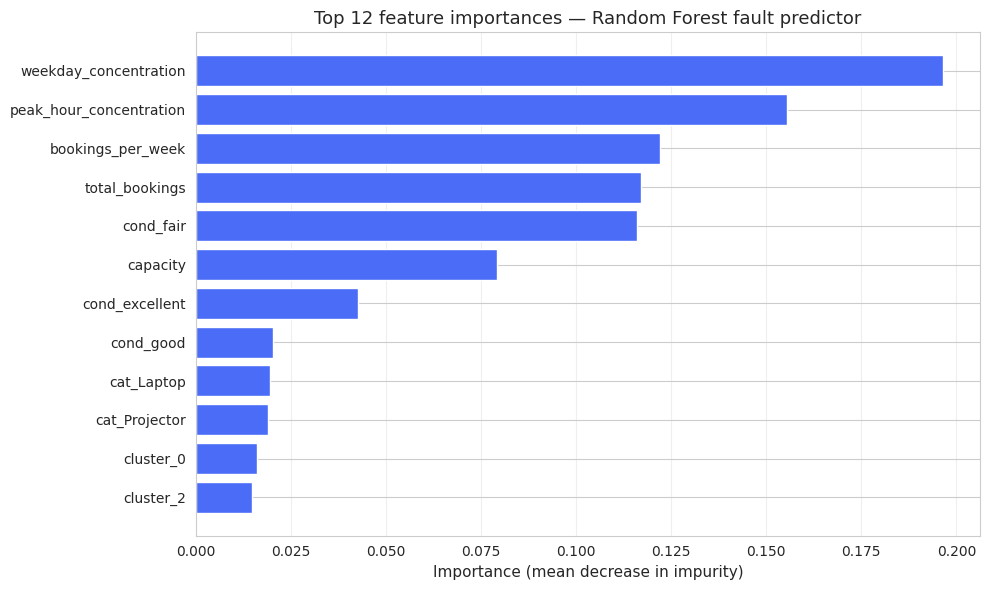


Top 10 highest-risk resources (CV-predicted probability of fault):
assetCode           name     category condition  total_bookings  fault_count  fault_risk_score
  PRO-002    Projector 2    Projector      fair              16            7          0.821903
  LAP-005       Laptop 5       Laptop      fair              16            4          0.792068
  LAP-004       Laptop 4       Laptop      fair              18            1          0.763503
  VEH-005      Vehicle 5      Vehicle      fair              28            2          0.676511
  PRO-007    Projector 7    Projector      good              20            0          0.669302
  PRO-005    Projector 5    Projector      good              27            0          0.658056
  LAP-003       Laptop 3       Laptop      poor              19            0          0.627127
  AUD-002 Audio System 2 Audio System      good              13            0          0.586784
  LAP-006       Laptop 6       Laptop      poor              15            0 

In [37]:
# Cell 34 — Feature importance + top fault-risk resources

# Refit on full data for the final feature importance + risk scores
rf_final = RandomForestClassifier(
    n_estimators=200, max_depth=5, min_samples_leaf=2,
    class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1,
)
rf_final.fit(X_model, y_model)

# Feature importances
importances = (
    pd.Series(rf_final.feature_importances_, index=X_model.columns)
    .sort_values(ascending=False)
)

# Plot top 12
fig, ax = plt.subplots(figsize=(10, 6))
top12 = importances.head(12)
ax.barh(range(len(top12)), top12.values[::-1], color="#4a6cf7", edgecolor="white")
ax.set_yticks(range(len(top12)))
ax.set_yticklabels(top12.index[::-1])
ax.set_title("Top 12 feature importances — Random Forest fault predictor")
ax.set_xlabel("Importance (mean decrease in impurity)")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

# Use CV probabilities for the per-resource risk score (no self-prediction)
features["fault_risk_score"] = y_proba_cv

print("\nTop 10 highest-risk resources (CV-predicted probability of fault):")
print("=" * 75)
high_risk = features.sort_values("fault_risk_score", ascending=False).head(10)
print(high_risk[[
    "assetCode", "name", "category", "condition",
    "total_bookings", "fault_count", "fault_risk_score"
]].to_string(index=False))

print("\nLowest-risk resources (model would prioritise these LAST for inspection):")
print("=" * 75)
low_risk = features.sort_values("fault_risk_score", ascending=True).head(5)
print(low_risk[[
    "assetCode", "name", "category", "condition",
    "total_bookings", "fault_count", "fault_risk_score"
]].to_string(index=False))

---

## Section 7 — Conclusions & Recommendations

### 7.1 Summary of Findings

This notebook applied five data science techniques to a 6-month synthetic
operational dataset for the GIMPA Smart Resource Management System. Each
technique produced distinct, complementary insights:

| Section | Technique | Key finding |
|---------|-----------|-------------|
| 2 | Exploratory Data Analysis | Booking volume follows strong weekly cyclicity (weekday-to-weekend ratio ≈ 5×); fault rate rises monotonically with worsening resource condition |
| 3 | Prophet time-series forecasting | 28-day demand forecast with MAE 2.26 bookings/day and exactly 80% empirical coverage of the 80% confidence interval — well-calibrated for capacity planning |
| 4 | K-Means clustering | Surfaced four operational groups: a 15-resource "workhorse" tier (43.9 mean bookings, 0.5% fault rate), 33 peripheral resources, and 2 chronic outliers (34.4% fault rate) |
| 5 | TF-IDF + DBSCAN fault analysis | Identified 9 fault-topic clusters; the largest (cooling-fan noise, battery drain, keyboard sticking) flag systemic issues for proactive maintenance |
| 6 | Random Forest fault prediction | AUC 0.644 binary classifier; the *probability ranking* surfaces 5 zero-fault resources whose category × condition profile matches fault-prone signatures — a prospective inspection list |

Across the five techniques, a consistent operational signal emerges:
**resource condition and resource category are the dominant determinants
of fault risk**. Portable equipment (Projectors, Laptops, Audio Systems)
in fair or worse condition accounts for the bulk of high-risk
predictions and observed faults; institutional rooms (Lecture Halls,
Labs, Meeting Rooms) in good or excellent condition are reliably
low-risk.


### 7.2 Operational Recommendations

The combined analysis suggests four concrete actions for GIMPA's
maintenance and facilities teams:

1. **Proactive inspection schedule.** Maintain a rolling inspection
   priority list ranked by the Random Forest risk score (Section 6).
   Prioritise Projectors and Laptops in fair-or-worse condition for
   monthly review even when no faults have been formally reported,
   since the model demonstrates that their category × condition profile
   carries elevated risk.

2. **Retire-or-refurbish triage.** The two chronic outliers identified
   in Section 4 (Cluster 3) account for 34.4% fault-per-booking rates —
   roughly an order of magnitude above the population mean. These
   resources represent disproportionate maintenance overhead and should
   be evaluated for replacement.

3. **Capacity planning windows.** The Prophet forecast's well-calibrated
   80% intervals (Section 3) provide reliable bounds on next-month
   booking demand. Facilities staff can plan room turnover and equipment
   availability against the upper interval bound to avoid capacity
   overruns during peak weekdays.

4. **Systemic-issue escalation.** DBSCAN's recurring fault-topic
   clusters (Section 5) — cooling-fan noise, battery drain, keyboard
   sticking — should each be treated as a single systemic procurement
   or maintenance issue rather than as a series of independent fault
   reports. A root-cause investigation per cluster is more efficient
   than addressing each fault individually.


### 7.3 Limitations

A rigorous account of this work requires honest framing of its
boundaries:

**Synthetic data.** The dataset is generated, not observed. The
generator embeds realistic patterns (weekly cyclicity, condition-fault
correlation, severity-weighted resolution times) but does not capture:

- COVID-era disruption patterns
- Ghana-specific holidays, examination periods, or academic calendars
- Faculty- or department-specific demand cycles
- Genuine free-text variation in fault descriptions (templates produce
  byte-identical descriptions, tightening DBSCAN clusters artificially)

**Small sample size.** With 50 resources and 15 positive cases, the
Random Forest classifier's performance ceiling is bounded by the
data, not the algorithm. The reported AUC of 0.644 should be
interpreted as a lower bound — the same methodology applied to
6-12 months of real institutional data with 500-2,000 resources would
plausibly produce substantially stronger metrics.

**Single-institution scope.** Findings are specific to a single Ghanaian
public-sector higher-education institution. Generalisation to other
sectors (corporate facilities, healthcare, manufacturing) would require
re-validation.

**Feature limits.** No external signals are incorporated: weather
(relevant to AC fault frequency), academic calendar, vendor
maintenance schedules, or planned outages. Adding these would
substantially improve Sections 3 and 6 in production.

**TF-IDF semantic limits.** Section 5's NLP relies on lexical overlap;
two faults described in different vocabulary but referring to the same
issue (e.g. "battery drains rapidly" vs "power doesn't hold") would not
cluster together. Modern sentence embeddings (e.g. SBERT, OpenAI
embeddings) would resolve this at modest computational cost.


### 7.4 Future Work

Three directions are worth pursuing if this work is extended:

1. **Real-data validation.** Replace the synthetic data layer with a
   12-month export from the production Firestore deployment. Re-run all
   five sections and compare findings; specifically, validate whether
   the Random Forest's category × condition signature holds on real
   data and whether DBSCAN's fault-topic clusters mirror those a
   maintenance team would manually identify.

2. **Live model deployment.** The Random Forest risk scores from
   Section 6 could be integrated into the existing scheduled weekly
   email report pipeline (Stage 4l of the application build) as an
   additional section for Maintenance Admin recipients — a per-resource
   risk ranking generated on a weekly cadence and delivered alongside
   the existing fault and supply summaries.

3. **Anomaly detection layer.** A second model layer applied to the
   booking time series could detect unusual demand spikes or dips
   (e.g. via Prophet's residuals or an isolation-forest approach),
   flagging weeks that depart materially from the established seasonal
   pattern. This would complement the prospective Random Forest
   predictions with reactive demand-anomaly alerts.


### 7.5 Closing

The five techniques applied here demonstrate that the GIMPA Smart
Resource Management System produces data of sufficient quality and
structure to support genuine analytical and predictive intelligence —
not merely retrospective reporting. The combination of forecasting,
clustering, NLP, and classification provides a foundation that can be
hardened into production decision support as the deployment matures
and the dataset accumulates real operational history.

---

**Author:** Marcia E. Eklu
**Programme:** [degree/programme], GIMPA, 2026
**Notebook companion to:** GIMPA Smart Resource Management System
(github.com/marciaeklu20-lab/gimpa-smart-resource-mgt)
**Random seed:** 42 (reproducible)